# Foundations of Machine learning

Problem Set 4

Emily Fu

In [1]:
# import packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# parallel computing using dask
from dask import delayed, compute

In [2]:
# set parameters

# set seed
seed = 420

# replications
R = 10000

# time periods

# what i'm using for most of the plots
T_other = 100
# for the two armed plots
T_1d = 200
# for question 2d
T_multiple = [100, 200, 300]

# some thetas

# generate thetas with k = 2 and theta_1 = 0.5
thetas_twoarm = []
# fill in theta_2 from 0.1 to 0.9 in increments of 0.1
for theta_2 in np.arange(0.1, 1.0, 0.1):
    thetas_twoarm.append([0.5, theta_2])

single_theta_threearm = [0.2, 0.5, 0.8]

thetas_threearm = [[0.2, 0.5, 0.8], [0.6, 0.5, 0.2], [0.4, 0.9, 0.6], [0.45, 0.5, 0.55]]

1. In this problem, you are asked to simulate data for a Bernoulli bandit problem, where 

$D_t \in \{1,...,k\}$, $Y_t = Y^{D}_t$ , $Y^{d}_t ∼ \text{Ber}( \theta_{d} )$,

and treatment is assigned using Thompson sampling with a uniform prior, $(\theta_{1},...,\theta_{k}) ∼ U([0,1]^k)$. Recall that Thompson sampling assigns 

$ D_t = \text{argmax}_d \: \hat{\theta}^{d}_t $, 

where $\hat{\theta}_t$ is a draw from the posterior after period $t−1$.

a) Set up a function which accepts a sample size $T$ and a k-vector $(\theta_{1},...,\theta_{k})$ as its arguments, and returns a history $(D_t,Y_t)^T_{t=1}$ generated based on the Bernoulli bandit model and Thompson sampling

In [3]:
# question 1a, question 2a
def bernoulli_bandit(T, theta, seed=420, M=1000, exploration=False):
    # for generating from distributions
    rng = np.random.default_rng(seed)

    # get the amount of treatments from their true expected outcomes
    k = len(theta)
    
    # initialise arrays to store the selected treatments and observed outcomes
    D_t = np.zeros(T, dtype=int)
    Y_t = np.zeros(T)
    
    # the posterior for theta_d at time t + 1 is a Beta distribution with parameters
    # start with uniform prior over theta on [0, 1]^k
    # 1 + number of successes
    alpha = np.ones(k)
    # 1 + number of failures
    beta = np.ones(k)
    
    for t in range(T):
        # case for exploration sampling
        if exploration:
            # sample from the Beta distribution for each treatment
            draws = rng.beta(alpha, beta, size=(M, k))
            # but now need to actually get a distribution i need to like approximate it
            # find which treatment is best in each simulated world
            best_arms = np.argmax(draws, axis=1)
            # count how often each treatmnet is the largest, use those frequencies as an estimate for p
            p_t = np.bincount(best_arms, minlength=k) / M
            # print(p_t)

            # calculate q_t for exploration sampling
            weights = p_t * (1 - p_t)
            denom = weights.sum()
            
            # in the limit, half the observations are assigned to the best treatment
            if denom > 0:
                q_t = weights / denom
            # here, one of the p_t is 1 and the rest are 0
            # so simulated posterior probabilities have already converged to putting all the weight on one treatment
            else:
                # put all the weight on the best treatment, but still explore the other treatments a little bit
                best_arm = np.argmax(p_t)
                q_t = np.ones(k) * (0.5 / (k - 1))
                q_t[best_arm] = 0.5

            # choose with probabilities given by q_t instead of directly from the beta distribution
            action = rng.choice(k, p=q_t)
            D_t[t] = action
        # thompson sampling
        else:
            # sample from the Beta distribution for each treatment
            samples = rng.beta(alpha, beta)
            # print(samples)
            
            # find which treatment gave the highest sample and select that treatment
            action = np.argmax(samples)
            # store which treatment this corresponds to
            D_t[t] = action
        
        # assume that outcome follows a Bernoulli distribution with parameter theta[action]
        outcome = rng.binomial(1, theta[action])
        Y_t[t] = outcome
        # print(outcome)
        
        # update alpha and beta parameters of posterior based on the observed outcome
        if outcome == 1:
            # another success
            alpha[action] += outcome
        else:
            # not success
            beta[action] += 1 - outcome
    
    # mean for each treamtnet after period T (beta distribution expected value)
    posterior_means = alpha / (alpha + beta)

    # treatment with highest posterior mean at time T
    d_highest_posterior_mean = np.argmax(posterior_means)
    
    # hash return
    return ({'D_t': D_t, 
             'Y_t': Y_t, 
             'd_highest_posterior_mean': d_highest_posterior_mean})

In [6]:
# example use of bernoulli_bandit for thompson samplin

history_1a = bernoulli_bandit(T_other, single_theta_threearm, seed=seed)

# see that the algorithm is assigning treatment with higher theta more often over time
print(f'treatment history: {history_1a['D_t']}')
print(f'Treatment with the highest posterior mean at time T: {history_1a['d_highest_posterior_mean']}')

treatment history: [1 2 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 1 2]
Treatment with the highest posterior mean at time T: 2


b) Write a second function which takes the same arguments, plus a number of replications $R$, and evaluates the first function $R$ times (using parallel computing; for instance the `future` package). This function should return 4 vectors of length $T$: The averages of $Y_t$, $\theta^{D_t}$, ${1(D_t = \text{argmax}_d \: \theta_{d})}$, and $\text{max} \: \theta_{d} − \theta^{D_t} $, for each time period $t$.

Splitting this into one kind-of-lambda function and one that does the parallel computing (from what I've found, there are multiple parallel computing options for Python and I've used [`dask`](https://docs.dask.org/en/stable/))

In [ ]:
# question 1b, question 2b
def calculate_replication(T, theta, seed=420, exploration=False):
    # format of theta
    theta = np.asarray(theta, dtype=float)

    # get the actions and outcomes for T time steps
    result = bernoulli_bandit(T, theta, seed=seed, exploration=exploration)
    D_t = result['D_t']
    Y_t = result['Y_t']
    d_highest_posterior_mean = result['d_highest_posterior_mean']

    # best treatment and its theta value
    best_arm = np.argmax(theta)
    best_theta = np.max(theta)
    
    # get the theta value of the selected treatment at each time step
    theta_Dt = theta[D_t]
    # how many times the optimal treatment was selected at each time step
    optimal_indicator = (D_t == best_arm).astype(float)
    # calculate regret at each time step
    regret_t = best_theta - theta_Dt

    # calculate policy regret at time T
    policy_regret = best_theta - theta[d_highest_posterior_mean]
    # indicator for whether the policy at time T selects the best treatment
    best_arm_policy_indicator = float(d_highest_posterior_mean == best_arm)

    return ({'Y_t': Y_t,
             'theta_Dt': theta_Dt,
             'optimal_indicator': optimal_indicator,
             'regret_t': regret_t,
             'd_highest_posterior_mean': d_highest_posterior_mean,
             'policy_regret': policy_regret,
             'best_arm_policy_indicator': best_arm_policy_indicator})

# question 1b, question 2b
def evaluate_bandit(T, theta, R, seed=420, exploration=False):
    # format of theta
    theta = np.asarray(theta, dtype=float)

    # actually do it for the R replications
    tasks = [delayed(calculate_replication)(T, theta, seed + r, exploration) for r in range(R)]

    # compute the results in parallel using dask
    results = compute(*tasks, scheduler='threads')

    # aggregate results across replications
    Y_all = np.array([res['Y_t'] for res in results])
    thetaDt_all = np.array([res['theta_Dt'] for res in results])
    opt_all = np.array([res['optimal_indicator'] for res in results])
    regret_all = np.array([res['regret_t'] for res in results])
    d_star_all = np.array([res['d_highest_posterior_mean'] for res in results])
    policy_regret_all = np.array([res['policy_regret'] for res in results])
    best_arm_policy_all = np.array([res['best_arm_policy_indicator'] for res in results])

    # averagevalues of Y_t, theta_Dt, optimal indicator, and regret_t across the R replications
    avg_Y_t = Y_all.mean(axis=0)
    avg_theta_Dt = thetaDt_all.mean(axis=0)
    avg_optimal = opt_all.mean(axis=0)
    avg_regret_t = regret_all.mean(axis=0)

    # cumulative average regret and average of cumulative average regret across the R replications
    avg_cum_regret_t = np.cumsum(avg_regret_t)
    avg_cumavg_regret_t = avg_cum_regret_t / np.arange(1, T + 1)

    # probability of choosing the best treatment
    avg_policy_regret = policy_regret_all.mean()
    prob_best_arm_policy = best_arm_policy_all.mean()

    return ({'avg_Y_t': avg_Y_t,
             'avg_theta_Dt': avg_theta_Dt,
             'avg_optimal': avg_optimal,
             'avg_regret_t': avg_regret_t,
             'avg_cum_regret_t': avg_cum_regret_t,
             'avg_cumavg_regret_t': avg_cumavg_regret_t,
             'avg_policy_regret': avg_policy_regret,
             'prob_best_arm_policy': prob_best_arm_policy,
             'd_star_all': d_star_all})

c) Pick a fixed vector of parameters $(\theta_{1},...,\theta_{k})$ and a time horizon $T$ and use the second function to plot the average (across replications) of cumulative average regret

$$\frac{1}{T} \sum_{1 \leq t \leq T} [(\text{max}_{d} \: \theta^{d}) - \theta^{D_t}]$$

as a function of T, using a large number of replications $R$ (such as $R = 10000$). Repeat this for several different choices of $(\theta_{1},...,\theta_{k})$. How does the result relate to the theoretical regret rate bound discussed in class, and to Agrawal and Goyal (2012)?

The result from the slides says that expected regret (difference to optimal policy) goes to 0 at a rate of $\text{O}(\log(T)/T)$ for the UCB algorithm. For large $T$, similar upper bounds on $\mathop{\mathbb{E}}[T_{d}^{T}]$ (the amount of times the treatment is used) for the UCB algorithm hold for Thompson sampling. Then, Theorem 2 from Agrawal and Goyal (2012) shows that the Thompson Sampling algorithm also has logarithmic decay in expected regret

For the N-armed stochastic bandit problem, Thompson sampling has expected regret

$$\mathop{\mathbb{E}}[R(T)] \leq \text{O} ((\sum_{a = 2}^{N} \frac{1}{\Delta^{2}_{a}})^2 (\ln T))$$

They're using $a$ to denote each treatment out of $N$ total treatments, and $\mathop{\mathbb{E}}[R(T)]$ would be expected cumulative regret. This means they showed that cumulative regret grows logarithmically in time, so if I divide by $T$, I get the same $\text{O}(\log(T)/T)$ rate for Thompson Sampling.

Here, the thing I'm plotting is cumulative regret divided by time across all my replications, which is the sample version of how expected regret $R_T$ is defined in the slides and it is decreasing in $T$ towards zero, but decreases slower with higher $T$. The point of this is that as you get more history, you learn with the Thompson sampling algorithm which treatment is more likely to succeed. Then, cumulative regret grows slowly and its average will go to zero. Every time we were observing our outcome and updating the posterior, we were increasing the parameters in the beta distribution so that the more successful treatments are more likely to be chosen again which makes average regret decrease. However, once the regret is already small and the probability that Thompson sampling picks the wrong treatment becomes very small, cumulative average regret will decrease by less. I chose a few $\theta$ s with different expected outcomes, and the ones with treatments that vary in expected outcome by a lot have higher average regret as T is small but that decay faster. One of my choices was $\theta = [0.45, 0.5, 0.55]$, which is much flatter than the others since the expeced outcomes are close to each other and so regret is always small and I think it wouldn't learn which one is the best treatment as fast.

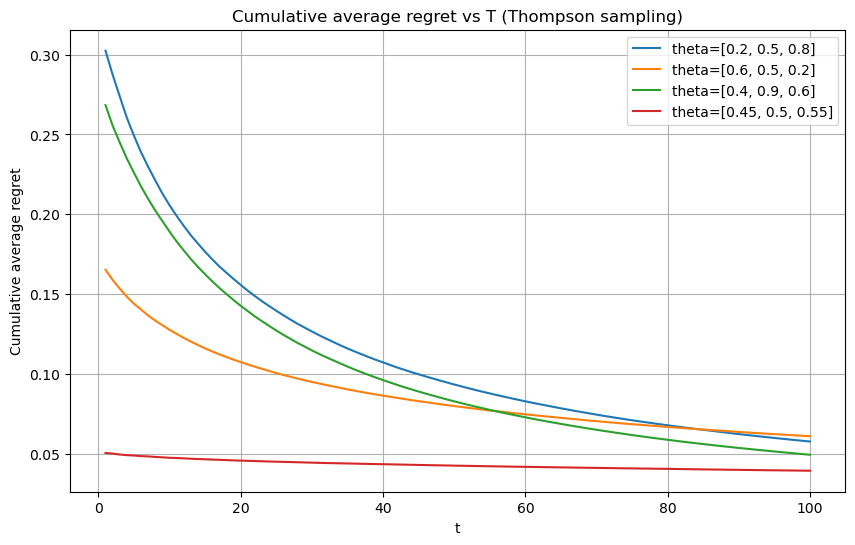

In [5]:
plt.figure(figsize=(10, 6))
# line up the times with the periods
x = np.arange(1, T_other + 1)

# calculate cumulative average regret for all thetas and plot them on the same graph
for i, theta in enumerate(thetas_threearm):
    avg_cumavg_regret = evaluate_bandit(T_other, theta, R, seed=seed)['avg_cumavg_regret_t']
    plt.plot(x, avg_cumavg_regret, label=f'theta={theta}')

plt.xlabel('t')
plt.ylabel('Cumulative average regret')
plt.title('Cumulative average regret vs T (Thompson sampling)')
plt.legend()
plt.grid(True)
plt.show()

d) Now let $k = 2$, fix $\theta_{1} = 0.5$ and $T = 200$. Plot cumulative average regret for $T$ as a function of $\theta_{2}$, for $\theta_{2} \in [0,1]$. Do the same for the share of observations assigned to the optimal treatment. How does the result relate to the local-to-zero asymptotics discussed in class, and to Figure 3 in Wager and Xu (2021)?

The share of observations assigned to optimal treatment is greater when $\theta_{2}$ is more different from $\theta_{1}$. This corresponds to the larger arm gaps in Wager and Xu (2021) Figure 3. In those cases, it's easier to distinguish which treatment is better, so the algorithm learns it quickly and exploits it, so the optimal treatment is assigned less perfectly as $\theta_{2}$ approaches 0.5. There are then fewer draws of the worse treatment and lower regret. If $\theta_{2} == \theta_{1}$, about half of observations are assigned to the optimal treatment. That is, there is no true optimal treatment since they have the same expected outcome and there are only two options.

There is a peak in cumulative average regret when $\theta_{2}$ is close but not equal to 0.5 (cumulative average regret is zero when they are equal since there's no cost to assigning either treatment), but it is lower when the arm gap is greater. This leaves the middle values to have higher cumulative average regret, which is seen in the non-monotone regret in Wager and Xu and the local-to-zero asymptotics discussions from the slides.

In [7]:
cumavg_regret_T = []
optimal_shares = []
for theta in thetas_twoarm:
    # get average optimal treatment assignment over time across replications for this theta
    avg_optimal = evaluate_bandit(T_1d, theta, R, seed=seed)['avg_optimal']
    # get cumulative average regret at time T for this theta
    avg_cumavg_regret = evaluate_bandit(T_1d, theta, R, seed=seed)['avg_cumavg_regret_t']
    ## share of observations assigned to optimal treatment at the end of T
    optimal_shares.append(avg_optimal[-1])  
    cumavg_regret_T.append(avg_cumavg_regret[-1])

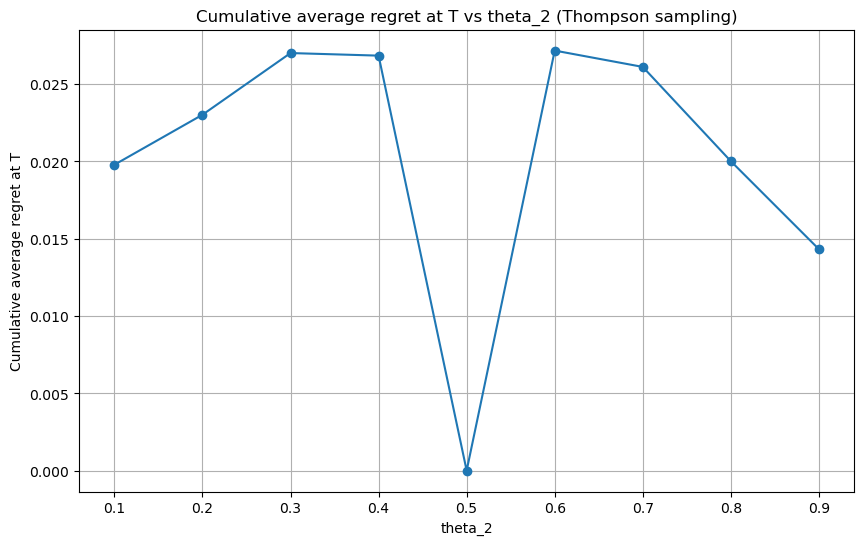

In [8]:
# plot cumulative average regret for T as a function of theta_2
plt.figure(figsize=(10, 6))

plt.plot(np.arange(0.1, 1.0, 0.1), cumavg_regret_T, marker='o')
plt.xlabel('theta_2')
plt.ylabel('Cumulative average regret at T')
plt.title('Cumulative average regret at T vs theta_2 (Thompson sampling)')
plt.grid(True)
plt.show()

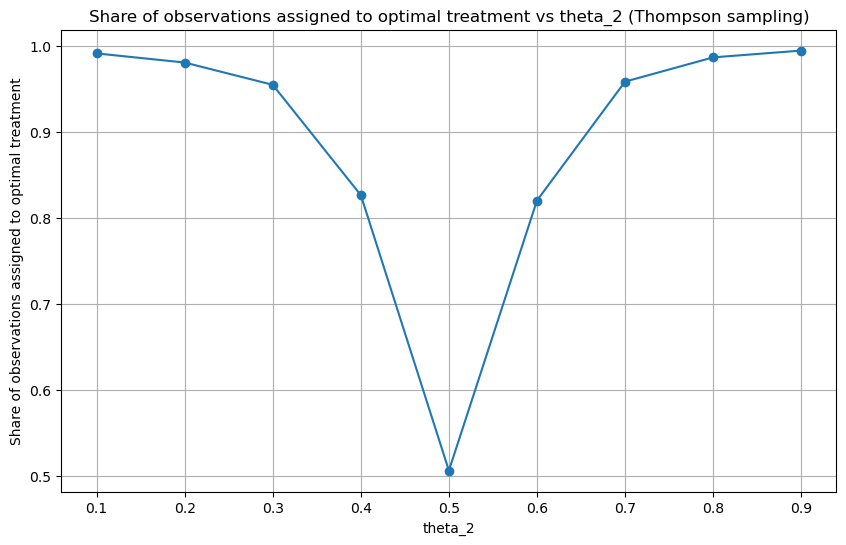

In [9]:
# plot share of observations assigned to the optimal treatment as a function of theta_2
plt.figure(figsize=(10, 6))
plt.plot(np.arange(0.1, 1.0, 0.1), optimal_shares, marker='o')
plt.xlabel('theta_2')
plt.ylabel('Share of observations assigned to optimal treatment')
plt.title('Share of observations assigned to optimal treatment vs theta_2 (Thompson sampling)')
plt.grid()
plt.show()

2. In this problem, we will again consider the Bernoulli bandit, and compare Thompson sampling to exploration sampling, as discussed in Kasy and Sautmann (2021).


a) Create a modified version of the first function from problem 1, where instead of Thompson sampling treatment is assigned using exploration sampling. Let this function additionally return the treatment $d^{*}_{T}$ with the highest posterior mean.

In [10]:
# example use of bernoulli_bandit_exploration

history_2a = bernoulli_bandit(T_other, single_theta_threearm, seed=seed, exploration=True)

print(f'treatment history: {history_2a['D_t']}')

# like i guess it's exploring more (mostly between treatments 1 ad 2 since treatment 0 is worse)
print(f'Treatment with the highest posterior mean at time T: {history_2a['d_highest_posterior_mean']}')

treatment history: [1 1 1 1 0 0 1 1 1 2 1 2 1 1 2 1 1 1 0 1 1 2 2 0 1 2 1 2 1 0 1 2 0 0 2 0 2
 0 1 0 2 1 2 2 2 1 2 2 2 2 1 1 1 1 1 1 0 1 2 2 0 1 2 2 1 2 1 2 1 1 2 2 2 1
 2 2 0 1 2 2 0 0 1 1 2 0 2 0 1 1 2 2 2 2 2 1 1 1 1 1]
Treatment with the highest posterior mean at time T: 2


b) Create a modified version of the second function from problem 1, again replacing Thompson sampling by exploration sampling. Thompson sampling assigns treatment $d$ with probability

$$q^{d}_{t} = \frac{p^{d}_{t} (1 − p^{d}_{t})}{\sum_{d'} p^{d'}_{t} (1 - p^{d'}_{t})} $$

where $p^{d}_{t}$ is the posterior probability that that treatment $d$ is optimal.

Let this function additionally return the average across replications of policy regret 

$$(\text{max}_d \theta^{d}) - \theta^{d^{*}_{T}}$$

and the probability of choosing the best arm, $P(d^{*}_{T} = \text{argmax}_d \theta_{d})$. Edit the second function from problem 1 to do the same for Thompson sampling.

I ended up only using three functions by adding a toggle between Thompson sampling and exploration sampling, so the work above includes 2(a) and 2(b).

c) Pick a fixed vector of parameters $(\theta^{1},...,\theta^{k})$ and a time horizon $T$ and calculate cumulative average regret as well as average policy regret, for both Thompson sampling and exploration sampling. Do so using a large number of replications $R$ (such as $R = 10000$). How does the result line up with the discussion and simulations of Kasy and Sautmann (2021)?

The key result of Kasy and Sautmann (2021) is that exploration sampling achieves the best possible rate of expected policy regret convergence to zero, subject to the constraint that, in the limit, half the observations are assigned to the best treatment. I wasn't exactly sure how to implement this share for the top treatment using the sampling from the previous parts of the code since I didn't exactly know what share to give to the rest of the options. I decided to split the rest of the share evenly. It also looks like cumulative average regret in exploration sampling is converging to a non-zero value rather than going to zero like Thompson sampling, which would happen given that the shares are assigned like that once my (simulated) posterior probabilities have already converged to putting all the weight on one treatment. 

In my output below, average policy regret is indeed larger in Thompson sampling. Similarly to the Kasy and Sautmann simulation results, Thompson sampling outperforms exploration sampling in terms of the decay of cumulative average regret, which comes from how exploration sampling deliberately allocates observations to less certain alternatives and Thompson sampling doesn't. The in-sample regret from our Thompson sampling lecture measures how much loss we get during the experiment because we sometimes assign worse treatments, so deliberately not always going for the best treatment in the posterior will make it worse. Policy regret is only about the loss of the final treatment decision after all history $T$, so exploration sampling has lower policy regret by doing more exploration. 

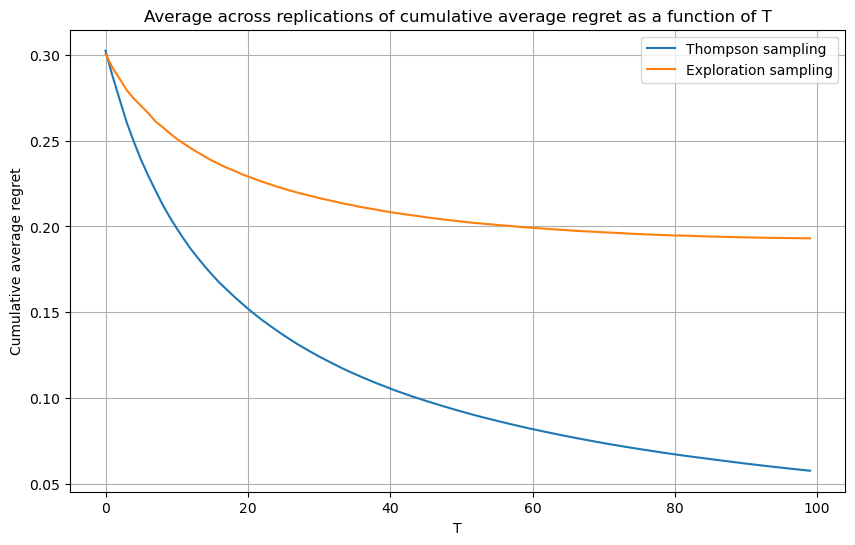

In [11]:
# plot cumulative average regret for both thompson sampling and exploration sampling in one plot
plt.figure(figsize=(10, 6))
avg_cumavg_regret_thompson = evaluate_bandit(T_other, 
                                             single_theta_threearm, 
                                             R, seed=seed, 
                                             exploration=False)['avg_cumavg_regret_t']
avg_cumavg_regret_exploration = evaluate_bandit(T_other, 
                                                single_theta_threearm, 
                                                R, seed=seed, 
                                                exploration=True)['avg_cumavg_regret_t']
plt.plot(avg_cumavg_regret_thompson, label='Thompson sampling')
plt.plot(avg_cumavg_regret_exploration, label='Exploration sampling')
plt.xlabel('T')
plt.ylabel('Cumulative average regret')
plt.title('Average across replications of cumulative average regret as a function of T')
plt.legend()
plt.grid()
plt.show()


In [12]:
# average policy regret for both thompson sampling and exploration sampling
avg_cumavg_regret_exploration = evaluate_bandit(T_other, 
                                                single_theta_threearm, 
                                                R, seed=seed, 
                                                exploration=True)['avg_policy_regret']
avg_cumavg_regret_thompson = evaluate_bandit(T_other, 
                                             single_theta_threearm, 
                                             R, seed=seed, 
                                             exploration=False)['avg_policy_regret']

print(f'Average policy regret for exploration sampling: {avg_cumavg_regret_exploration}')
print(f'Average policy regret for Thompson sampling: {avg_cumavg_regret_thompson}')

Average policy regret for exploration sampling: 0.0003600000000000001
Average policy regret for Thompson sampling: 0.0010500000000000002


d) Repeat this exercise for several different parameter vectors $(\theta^{1},...,\theta^{k})$ and sample sizes T. Discuss any patterns you might find.

Exploration sampling always produces lower average policy regret than Thompson sampling, which means that it more often selects the best treatment. Cumulative average regret is always decreasing in T, higher with exploration sampling than Thompson sampling, but closer together when the expected treatment outcomes are closer together (exploration is much less costly when the expected outcomes are close together). Cumulative average regret is always lower when the expected treatment outcomes are closer togther.

Both cumulative average regret and policy regret both depend on how hard it is to distinguish the best treatment from the competitors. When the optimal treatment is less obvious, it takes longer history to learn this because you're more likely to get outcomes that are close together, which both means that it could be more likely to recommend the wrong treatment at the end and assign the wrong treatment in the middle.

In [13]:
methods = {'Thompson': False, 'Exploration': True}

# hashmap of outputs
results = {}

# loop through all thetas, time periods, and methods and store outputs in results
# it's giving bubblesort
for theta in thetas_threearm:
    theta_key = tuple(theta)
    for T in T_multiple:
        for method_name, exploration in methods.items():
            out = evaluate_bandit(T, theta, R, seed=seed, exploration=exploration)
            results[(theta_key, T, method_name)] = out

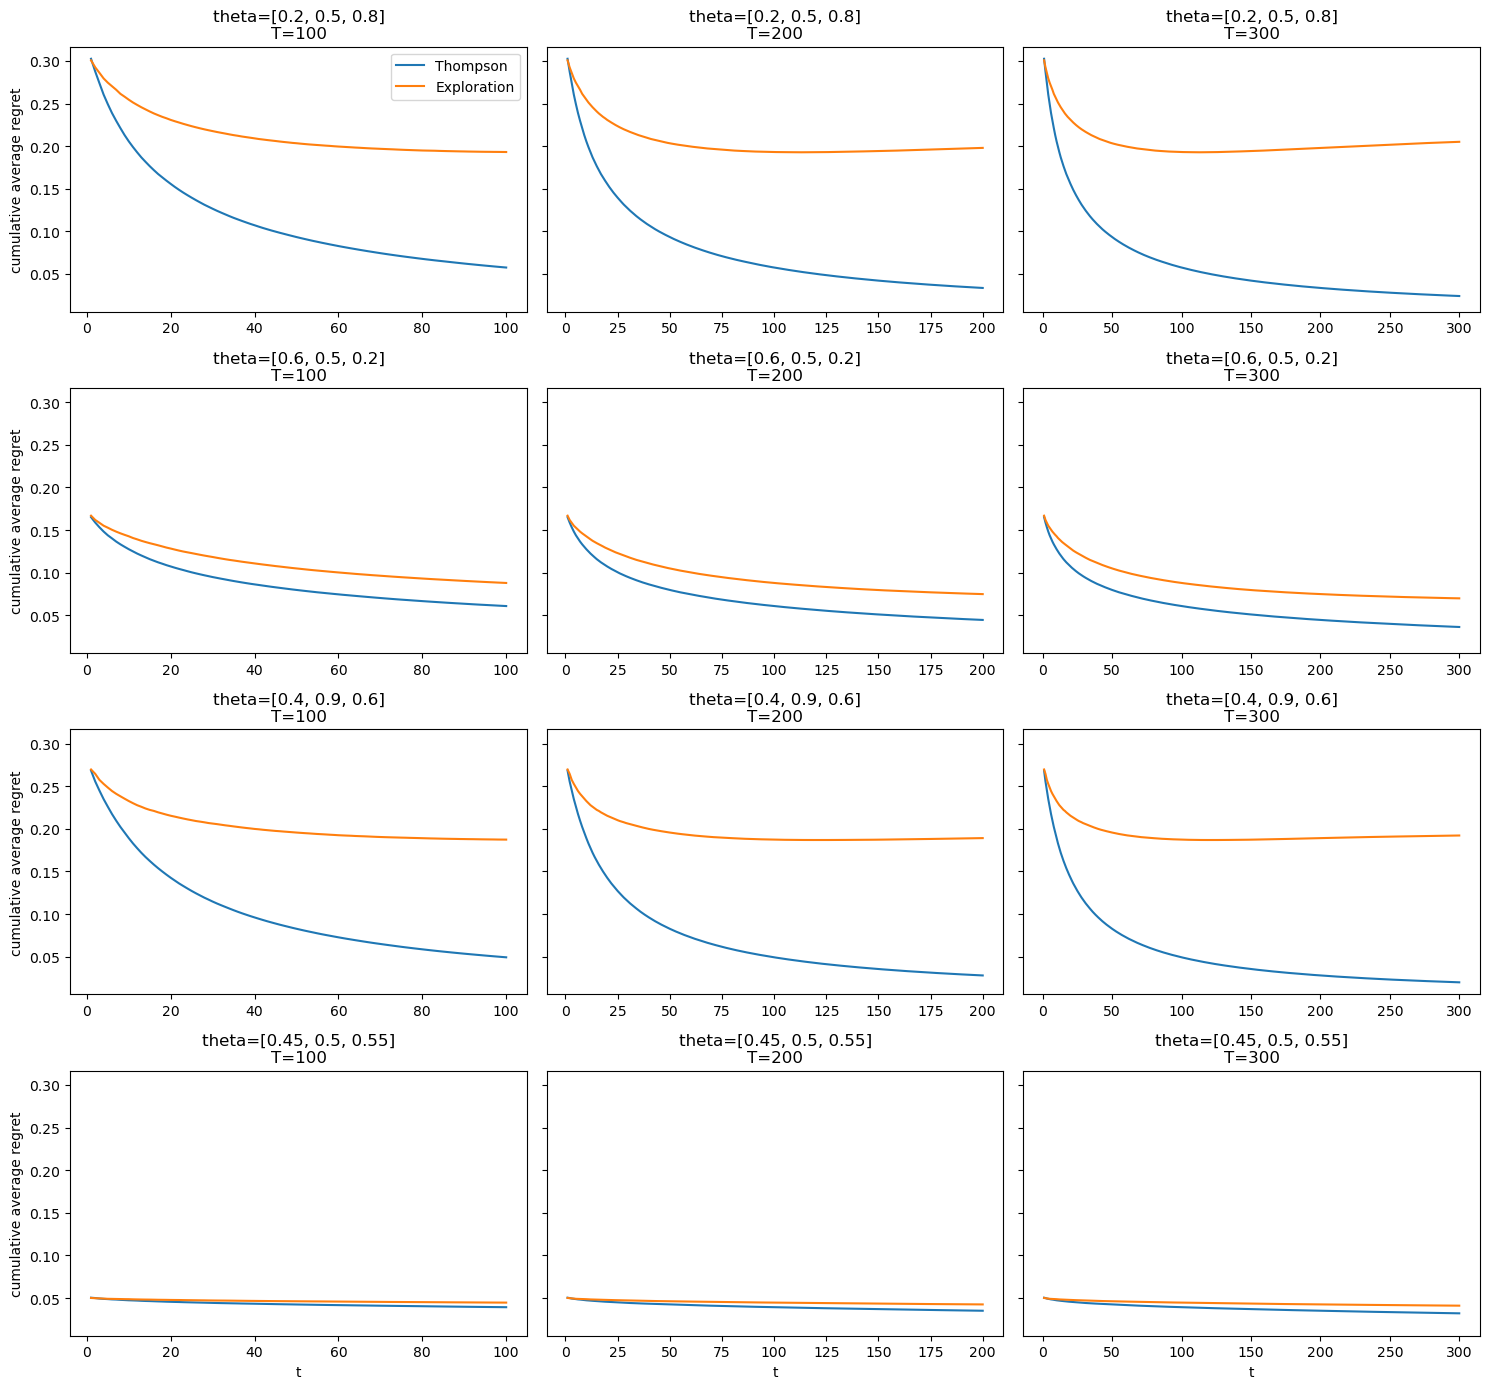

In [14]:
# plot cumulative average regret for all thetas, time periods, and methods

nrows = len(thetas_threearm)
ncols = len(T_multiple)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols, 3.5*nrows),
    sharey=True)

for i, theta in enumerate(thetas_threearm):
    theta_key = tuple(theta)
    for j, T in enumerate(T_multiple):
        ax = axes[i, j]
        x = np.arange(1, T + 1)

        for method_name in methods:
            y = results[(theta_key, T, method_name)]['avg_cumavg_regret_t']
            ax.plot(x, y, label=method_name)

        ax.set_title(f'theta={theta}\nT={T}')
        if i == nrows - 1:
            ax.set_xlabel('t')
        if j == 0:
            ax.set_ylabel('cumulative average regret')

        if i == 0 and j == 0:
            ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# create a dataframe to display the average policy regret and probability 
# of selecting the best treatment for each theta, T, and method
rows = []
for theta in thetas_threearm:
    theta_key = tuple(theta)
    for T in T_multiple:
        for method_name in methods:
            out = results[(theta_key, T, method_name)]
            rows.append({
                'theta': str(list(theta_key)),
                'T': T,
                'method': method_name,
                'avg_policy_regret': out['avg_policy_regret'],
                'prob_best_arm_policy': out['prob_best_arm_policy']})

df = pd.DataFrame(rows)

table = df.pivot_table(
    index=['theta', 'T'],
    columns='method',
    values=['avg_policy_regret', 'prob_best_arm_policy'])

display(table)

avg_policy_regret           prob_best_arm_policy  \
method                      Exploration  Thompson          Exploration   
theta             T                                                      
[0.2, 0.5, 0.8]   100           0.00036  0.001050               0.9988   
                  200           0.00000  0.000060               1.0000   
                  300           0.00000  0.000000               1.0000   
[0.4, 0.9, 0.6]   100           0.00012  0.000450               0.9996   
                  200           0.00000  0.000030               1.0000   
                  300           0.00000  0.000000               1.0000   
[0.45, 0.5, 0.55] 100           0.02651  0.027195               0.5959   
                  200           0.01963  0.019640               0.6812   
                  300           0.01488  0.015290               0.7447   
[0.6, 0.5, 0.2]   100           0.01727  0.018890               0.8276   
                  200           0.00832  0.010710               0.9168   
                  300           0.00420  0.006730               0.9580   

                                
method                Thompson  
theta             T             
[0.2, 0.5, 0.8]   100   0.9965  
                  200   0.9998  
                  300   1.0000  
[0.4, 0.9, 0.6]   100   0.9985  
                  200   0.9999  
                  300   1.0000  
[0.45, 0.5, 0.55] 100   0.5835  
                  200   0.6792  
                  300   0.7391  
[0.6, 0.5, 0.2]   100   0.8111  
                  200   0.8929  
                  300   0.9327

### (notes to self)

Exploration sampling deliberately allocates more observations to competing treatments whose optimality is uncertain. Because it keeps allocating observations to competing treatments, exploration sampling gathers more comparative information, which improves statistical power. As a result, exploration sampling assigns suboptimal treatments more frequently than Thompson sampling.

regret: regret at time t is the loss from not assigning the best treatment to that unit (how much we lose during the experiment because we sometimes assign suboptimal treatments)

policy regret(?): how bad the final chosen treatment is compared to the true best treatment

### Exerpts from Kasy and Sautmann (2021):

In Thompson sampling, the probability that a treatment $d$ is assigned to a given experimental unit arriving at $t$ is equal to the posterior probability $p^{d}_{t}$ (given outcomes up to $t−1$) that this treatment is in fact optimal.

Based on Thompson sampling, we propose a modified treatment assignment algorithm which we call exploration sampling. It replaces the Thompson assignment shares $($p^{1}_{t}, ..., $p^{k}_{t})$ with the following transformed shares:

$$q^{d}_{t} = S_t p^{d}_{t} (1 − p^{d}_{t}),$$

$$S_t = \frac{1}{\sum_{d} p^{d}_{t} (1 - p^{d}_{t})}$$

Exploration sampling would arise if we used Thompson sampling but never assigned the same treatment twice in a row, thus improving power for comparisons of relevant alternatives. Suppose that within a given wave, we sequentially draw treatment assignments based on the Thompson probabilities p, but the draw is repeated, if necessary, until the current unit is assigned a different treatment from the previous unit. 

The results show that exploration sampling consistently outperforms expected Thompson sampling in terms of average policy regret, and both outperform non-adaptive assignment. 

Our key result, Theorem 1, shows that exploration sampling achieves the best possible exponential rate of convergence, subject to the constraint that, in the limit, half the observations are assigned to the best treatment. It achieves in particular a better exponential rate than non-adaptive assignment, and converges much faster than Thompson sampling, which only converges polynomially.In-sample regret is the objective of bandit algorithms, for which Thompson sampling is rate-optimal, but exploration sampling is not. Here, Thompson performs best among the algorithms compared. 
